# Train and analyze MDP policies on ICU-Sepsis

This notebook uses the copied baseline repository in `code/COPER/policies` and the vendored `icu_sepsis` environment already present in this project.

Workflow:

1. Configure a small but runnable training setup for the copied policy baselines.
2. Train selected methods and collect their learned policy objects.
3. Compare them with random and expert policies on rollout statistics.
4. Display trajectories and policy summaries for qualitative analysis.

The notebook is written so it can be used both for quick testing and for longer analysis runs by editing the config cell.

In [15]:
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
import os
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
POLICIES_ROOT = PROJECT_ROOT / "policies"
ICU_SEPSIS_PACKAGE_ROOT = PROJECT_ROOT / "icu_sepsis" / "icu_sepsis"
# Parent of the `icu_sepsis_helpers` Python package (see icu_sepsis/icu_sepsis_helpers/icu_sepsis_helpers/)
ICU_SEPSIS_HELPERS_ROOT = PROJECT_ROOT / "icu_sepsis" / "icu_sepsis_helpers"

for path in (PROJECT_ROOT, POLICIES_ROOT, ICU_SEPSIS_PACKAGE_ROOT, ICU_SEPSIS_HELPERS_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.chdir(POLICIES_ROOT)

import icu_sepsis  # noqa: F401
from icu_sepsis_helpers.utils.mdp import value_iteration
from src.algos.dqn import run_dqn
from src.algos.ppo import run_ppo
from src.algos.qlearning import run_qlearning
from src.algos.sac import run_sac
from src.algos.sarsa import run_sarsa

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

def make_args(**kwargs):
    return SimpleNamespace(**kwargs)

In [16]:
# More episodes => less Monte-Carlo noise.
# TRAIN_EPISODES affects how stable the learned policies are.
# EVAL_EPISODES affects the precision of the reported mean return / survival rate.
TRAIN_EPISODES = 3000
EVAL_EPISODES = 2000
BASE_SEED = 7
ALGORITHMS = ["qlearning", "sarsa", "dqn", "ppo", "sac"]

ALGO_RUNNERS = {
    "qlearning": run_qlearning,
    "sarsa": run_sarsa,
    "dqn": run_dqn,
    "ppo": run_ppo,
    "sac": run_sac,
}

ALGO_CONFIGS = {
    "qlearning": dict(seed=BASE_SEED + 0, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=0.0025, buffer_size=1, gamma=1.0, batch_size=1, start_e=1.0, end_e=0.001, exploration_fraction=0.1),
    "sarsa": dict(seed=BASE_SEED + 1, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=0.0025, buffer_size=1, gamma=0.99, batch_size=1, start_e=1.0, end_e=0.05, exploration_fraction=0.3),
    "dqn": dict(seed=BASE_SEED + 2, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=2.5e-4, buffer_size=2000, gamma=0.99, tau=1.0, target_network_frequency=100, batch_size=32, start_e=1.0, end_e=0.05, exploration_fraction=0.3, learning_starts=100, train_frequency=4),
    "ppo": dict(seed=BASE_SEED + 3, num_envs=1, learning_rate=2.5e-4, num_steps=128, max_episodes=TRAIN_EPISODES, num_minibatches=4, gamma=1.0, gae_lambda=0.95, update_epochs=4, norm_adv=True, clip_coef=0.2, clip_vloss=True, ent_coef=1.0, vf_coef=0.5, max_grad_norm=0.5, target_kl=None),
    "sac": dict(seed=BASE_SEED + 4, num_envs=1, max_episodes=TRAIN_EPISODES, buffer_size=5000, gamma=0.99, tau=1.0, batch_size=32, learning_starts=100, policy_lr=3e-4, q_lr=3e-4, update_frequency=4, target_network_frequency=200, alpha=0.2, autotune=True, target_entropy_scale=0.89),
}

env = gym.make("Sepsis/ICU-Sepsis-v2")
mdp = env.unwrapped
expert_pi = np.asarray(mdp.expert_policy)
sofa_scores = np.asarray(mdp.sofa_scores)
optimal_actions, optimal_values = value_iteration(
    mdp.dynamics["tx_mat"], mdp.dynamics["r_mat"], mdp.gamma
)
N_STATES = env.observation_space.n
N_ACTIONS = env.action_space.n
env.close()

print(f"states={N_STATES}, actions={N_ACTIONS}, train_episodes={TRAIN_EPISODES}, eval_episodes={EVAL_EPISODES}")
pd.DataFrame({"algorithm": ALGORITHMS, "config": [str(ALGO_CONFIGS[name]) for name in ALGORITHMS]})

Value Iteration:   0%|          | 149/50000 [00:07<39:49, 20.86it/s]

states=716, actions=25, train_episodes=3000, eval_episodes=2000


,algorithm,config
0,qlearning,"{'seed': 7, 'num_envs': 1, 'max_episodes': 300..."
1,sarsa,"{'seed': 8, 'num_envs': 1, 'max_episodes': 300..."
2,dqn,"{'seed': 9, 'num_envs': 1, 'max_episodes': 300..."
3,ppo,"{'seed': 10, 'num_envs': 1, 'learning_rate': 0..."
4,sac,"{'seed': 11, 'num_envs': 1, 'max_episodes': 30..."


In [17]:
def train_algorithm(name: str):
    args = make_args(**ALGO_CONFIGS[name])
    print(f"training {name}...")
    result = ALGO_RUNNERS[name](args, use_tensorboard=False, use_wandb=False, return_agent=True)
    result["name"] = name
    return result


def training_summary(results):
    rows = []
    for result in results:
        rows.append(
            {
                "algorithm": result["name"],
                "episodes": int(len(result["returns"])),
                "mean_train_return_last_20": float(np.mean(result["returns"][-20:])),
                "mean_train_discounted_return_last_20": float(np.mean(result["discounted_returns"][-20:])),
                "mean_train_length_last_20": float(np.mean(result["num_steps"][-20:])),
            }
        )
    return pd.DataFrame(rows).sort_values("algorithm").reset_index(drop=True)


def optimal_policy_training_row(
    optimal_actions: np.ndarray,
    *,
    train_episodes: int,
    base_seed: int,
    gamma: float,
) -> dict:
    """No SGD for the optimal policy: rollout stats over `train_episodes` episodes (same schema as training_summary)."""
    env = gym.make("Sepsis/ICU-Sepsis-v2")
    returns: list[float] = []
    discounted_returns: list[float] = []
    num_steps: list[int] = []
    try:
        for episode_idx in range(train_episodes):
            state, info = env.reset(seed=base_seed + episode_idx)
            done = False
            total_reward = 0.0
            disc_r = 0.0
            discount = 1.0
            n_steps = 0
            while not done:
                action = int(optimal_actions[int(state)])
                state, reward, terminated, truncated, info = env.step(action)
                r = float(reward)
                total_reward += r
                disc_r += r * discount
                discount *= gamma
                n_steps += 1
                done = bool(terminated or truncated)
            returns.append(total_reward)
            discounted_returns.append(disc_r)
            num_steps.append(n_steps)
    finally:
        env.close()

    ret = np.asarray(returns, dtype=float)
    disc = np.asarray(discounted_returns, dtype=float)
    steps = np.asarray(num_steps, dtype=float)
    return {
        "algorithm": "optimal",
        "episodes": int(train_episodes),
        "mean_train_return_last_20": float(np.mean(ret[-20:])),
        "mean_train_discounted_return_last_20": float(np.mean(disc[-20:])),
        "mean_train_length_last_20": float(np.mean(steps[-20:])),
    }


results = [train_algorithm(name) for name in ALGORITHMS]
train_df = training_summary(results)
# Same table columns; optimal comes from value iteration + rollouts (not SGD).
train_df = pd.concat(
    [train_df, pd.DataFrame([optimal_policy_training_row(
        optimal_actions,
        train_episodes=TRAIN_EPISODES,
        base_seed=BASE_SEED + 300,
        gamma=float(mdp.gamma),
    )])],
    ignore_index=True,
).sort_values("algorithm").reset_index(drop=True)
train_df

training qlearning...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1645, Episode: 93, Step: 1000, Return: 1.0, Episode length: 3
Steps: 1000
Mean Q Value: 0.06610497832298279
SPS: 1627, Episode: 191, Step: 2000, Return: 1.0, Episode length: 7
Steps: 2000
Mean Q Value: 0.0
SPS: 1606, Episode: 311, Step: 3000, Return: 1.0, Episode length: 11
Steps: 3000
Mean Q Value: 0.07675779610872269
SPS: 1586, Episode: 431, Step: 4000, Return: 0.0, Episode length: 9
Steps: 4000
Mean Q Value: 0.07701054960489273
SPS: 1575, Episode: 549, Step: 5000, Return: 1.0, Episode length: 2
Steps: 5000
Mean Q Value: 0.045855578035116196
SPS: 1569, Episode: 647, Step: 6000, Return: 1.0, Episode length: 20
Steps: 6000
Mean Q Value: 0.213080495595932
SPS: 1561, Episode: 769, Step: 7000, Return: 1.0, Episode length: 18
Steps: 7000
Mean Q Value: 0.21456821262836456
SPS: 1555, Episode: 886, Step: 8000, Return: 1.0, Episode length: 1
Steps: 8000
Mean Q Value: 0.2003527283668518
SPS: 1547, Episode:

,algorithm,episodes,mean_train_return_last_20,mean_train_discounted_return_last_20,mean_train_length_last_20
0,dqn,3000,0.85,0.757639,11.65
1,optimal,3000,0.75,0.750000,9.05
2,ppo,3000,0.70,0.700000,7.75
3,qlearning,3000,0.70,0.700000,10.35
4,sac,3000,0.60,0.561093,9.20
5,sarsa,3000,0.80,0.720042,12.70


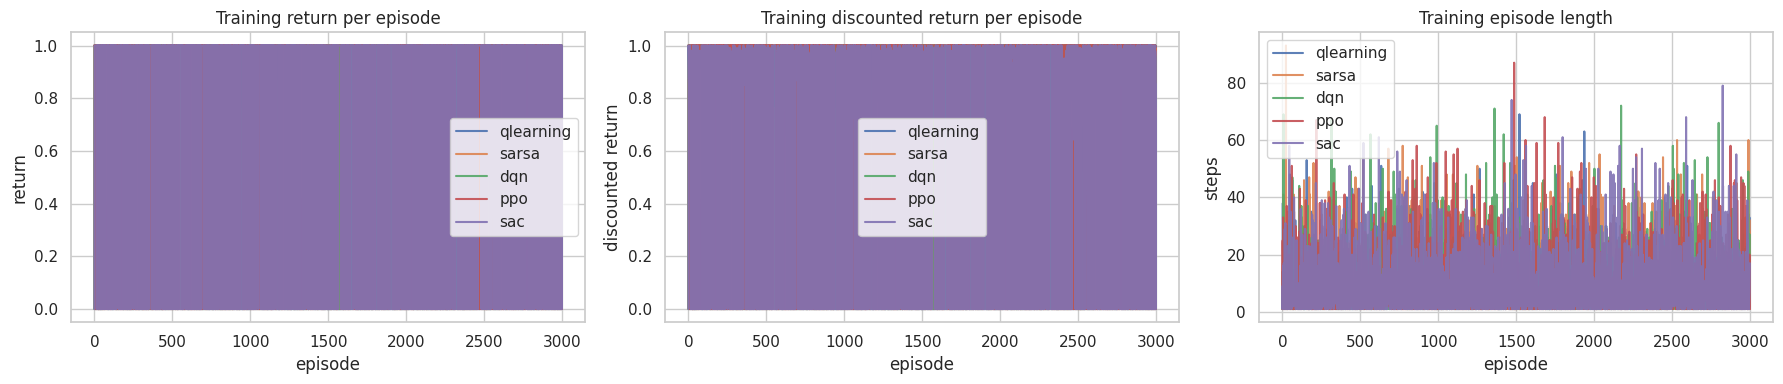

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for result in results:
    axes[0].plot(result["returns"], alpha=0.9, label=result["name"])
    axes[1].plot(result["discounted_returns"], alpha=0.9, label=result["name"])
    axes[2].plot(result["num_steps"], alpha=0.9, label=result["name"])

axes[0].set_title("Training return per episode")
axes[1].set_title("Training discounted return per episode")
axes[2].set_title("Training episode length")
axes[0].set_xlabel("episode")
axes[1].set_xlabel("episode")
axes[2].set_xlabel("episode")
axes[0].set_ylabel("return")
axes[1].set_ylabel("discounted return")
axes[2].set_ylabel("steps")
for ax in axes:
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [19]:
def encode_single_state(state: int, n_states: int) -> torch.Tensor:
    return torch.nn.functional.one_hot(torch.tensor([state]), num_classes=n_states).float()


def single_action_mask(info: dict, n_actions: int) -> torch.Tensor:
    mask = torch.zeros((1, n_actions), dtype=torch.float32)
    mask[0, info["admissible_actions"]] = 1.0
    return mask


def greedy_policy_from_result(result):
    model = result["agent"]
    algo = result["algo"]
    n_states = result["n_states"]
    n_actions = result["n_actions"]

    def policy(state: int, info: dict) -> int:
        obs = encode_single_state(int(state), n_states)
        mask = single_action_mask(info, n_actions)
        with torch.no_grad():
            if algo in {"qlearning", "sarsa", "dqn"}:
                q_values = model(obs, mask)
                return int(torch.argmax(q_values, dim=1).item())
            logits = model.actor(obs)
            logits = logits - ((1 - mask) * 1e10)
            return int(torch.argmax(logits, dim=1).item())

    return policy


def rollout_policy(policy_name: str, policy_fn, reset_seeds: np.ndarray):
    """Roll out a policy on a fixed list of reset seeds.

    Using the same reset seeds across policies makes per-policy comparisons less noisy/fairer.
    """
    env = gym.make("Sepsis/ICU-Sepsis-v2")
    traces = []
    try:
        for episode_idx, reset_seed in enumerate(reset_seeds):
            state, info = env.reset(seed=int(reset_seed))
            # Make stochastic policies reproducible per-episode.
            episode_rng = np.random.default_rng(int(reset_seed))

            done = False
            total_reward = 0.0
            episode_length = 0
            trace = {
                "policy": policy_name,
                "reset_seed": int(reset_seed),
                "states": [int(state)],
                "actions": [],
                "rewards": [],
                "sofa": [float(env.unwrapped.sofa_scores[int(state)])],
            }
            while not done:
                try:
                    action = int(policy_fn(int(state), info, episode_rng))
                except TypeError:
                    action = int(policy_fn(int(state), info))

                next_state, reward, terminated, truncated, info = env.step(action)
                state = int(next_state)
                total_reward += float(reward)
                episode_length += 1
                trace["actions"].append(action)
                trace["rewards"].append(float(reward))
                trace["states"].append(state)
                trace["sofa"].append(float(env.unwrapped.sofa_scores[state]))
                done = bool(terminated or truncated)
            trace["episode_return"] = total_reward
            trace["episode_length"] = episode_length
            traces.append(trace)
    finally:
        env.close()
    return traces


def summarize_rollouts(policy_name: str, traces):
    returns = np.array([trace["episode_return"] for trace in traces], dtype=float)
    lengths = np.array([trace["episode_length"] for trace in traces], dtype=float)
    n = max(1, len(returns))

    mean_return = float(returns.mean())
    std_return = float(returns.std(ddof=0))
    stderr_return = float(std_return / np.sqrt(n))
    ci95_halfwidth = float(1.96 * stderr_return)

    survival_rate = float((returns > 0).mean())
    # Approx. binomial standard error (ok for large n)
    stderr_survival = float(np.sqrt(max(1e-12, survival_rate * (1 - survival_rate)) / n))

    return {
        "policy": policy_name,
        "n_episodes": int(n),
        "mean_return": mean_return,
        "std_return": std_return,
        "stderr_return": stderr_return,
        "ci95_return": ci95_halfwidth,
        "mean_length": float(lengths.mean()),
        "survival_rate": survival_rate,
        "stderr_survival": stderr_survival,
    }


evaluation_rows = []
traces_by_policy = {}

# Use the SAME reset seeds for all policies (fairer comparison).
reset_seeds = (BASE_SEED + np.arange(EVAL_EPISODES, dtype=np.int64))

random_policy = lambda state, info, rng: int(rng.choice(info["admissible_actions"]))
expert_policy = lambda state, info, rng: int(rng.choice(expert_pi.shape[1], p=expert_pi[state]))
optimal_policy = lambda state, info: int(optimal_actions[state])

for name, policy_fn in [
    ("random", random_policy),
    ("expert", expert_policy),
    ("optimal", optimal_policy),
]:
    traces = rollout_policy(name, policy_fn, reset_seeds=reset_seeds)
    evaluation_rows.append(summarize_rollouts(name, traces))
    traces_by_policy[name] = traces

for result in results:
    policy_fn = greedy_policy_from_result(result)
    traces = rollout_policy(result["name"], policy_fn, reset_seeds=reset_seeds)
    evaluation_rows.append(summarize_rollouts(result["name"], traces))
    traces_by_policy[result["name"]] = traces

eval_df = pd.DataFrame(evaluation_rows).sort_values("mean_return", ascending=False).reset_index(drop=True)
eval_df

,policy,n_episodes,mean_return,std_return,stderr_return,ci95_return,mean_length,survival_rate,stderr_survival
0,optimal,2000,0.8745,0.331285,0.007408,0.014519,11.1050,0.8745,0.007408
1,ppo,2000,0.7965,0.402601,0.009002,0.017645,8.8315,0.7965,0.009002
2,dqn,2000,0.7925,0.405517,0.009068,0.017773,9.1500,0.7925,0.009068
3,qlearning,2000,0.7815,0.413228,0.009240,0.018111,7.5725,0.7815,0.009240
4,sac,2000,0.7785,0.415256,0.009285,0.018199,9.8395,0.7785,0.009285
5,expert,2000,0.7730,0.418893,0.009367,0.018359,8.8890,0.7730,0.009367
6,random,2000,0.7725,0.419218,0.009374,0.018373,9.7725,0.7725,0.009374
7,sarsa,2000,0.7690,0.421472,0.009424,0.018472,8.0230,0.7690,0.009424


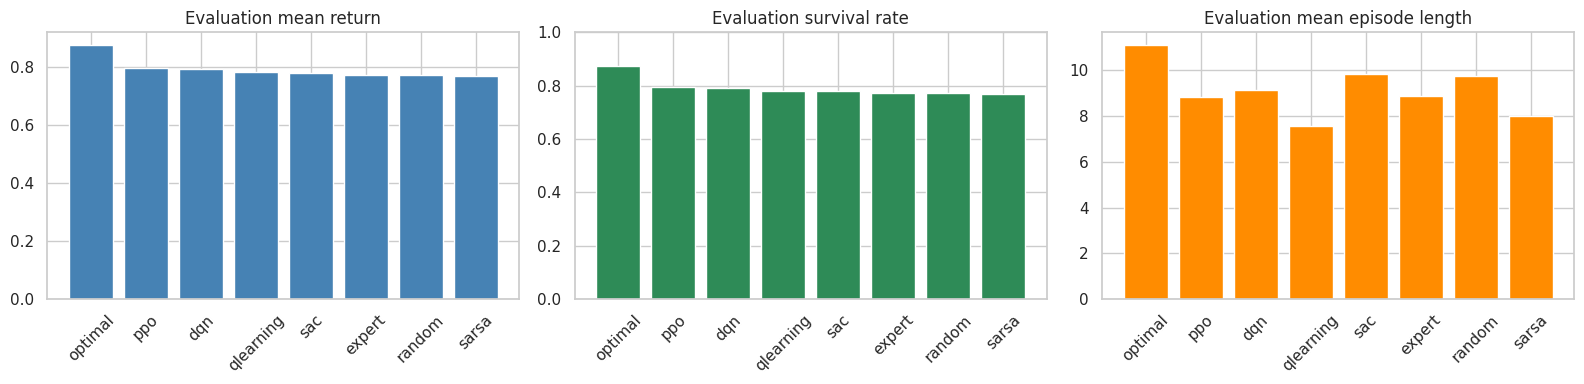

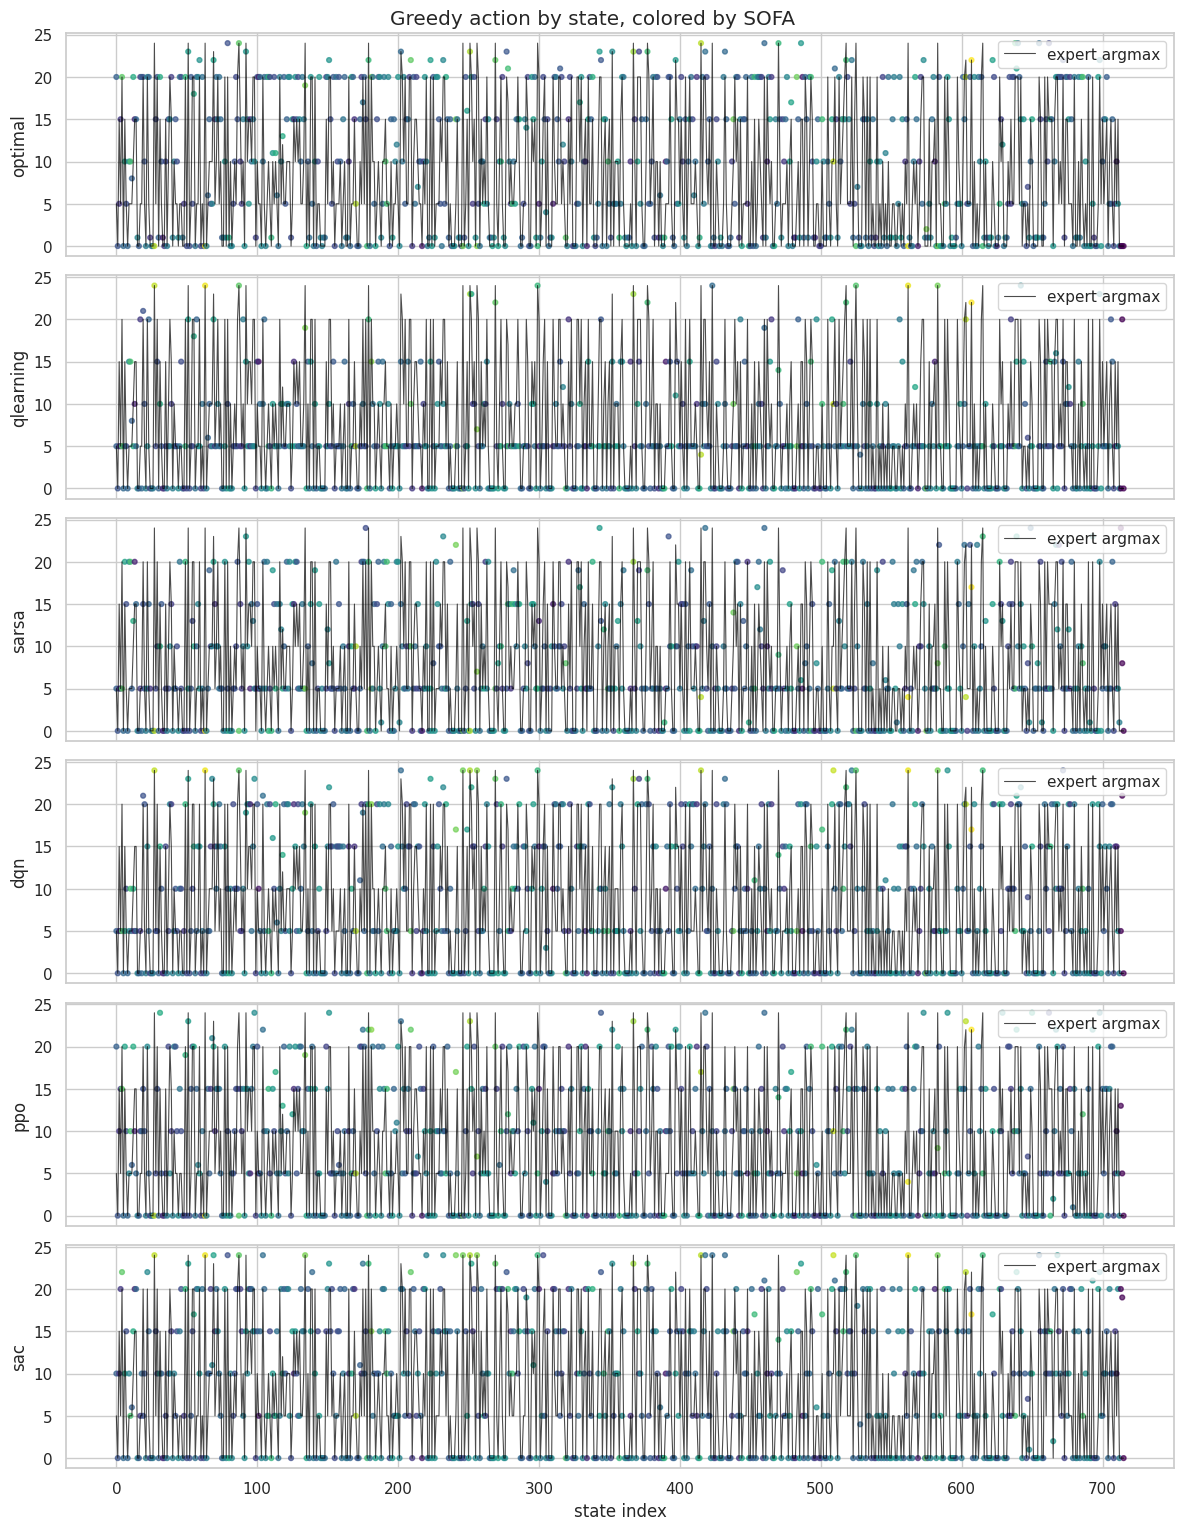

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ordered = eval_df.sort_values("mean_return", ascending=False)

axes[0].bar(ordered["policy"], ordered["mean_return"], color="steelblue")
axes[0].set_title("Evaluation mean return")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(ordered["policy"], ordered["survival_rate"], color="seagreen")
axes[1].set_title("Evaluation survival rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(ordered["policy"], ordered["mean_length"], color="darkorange")
axes[2].set_title("Evaluation mean episode length")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

policy_display_rows = []
policy_specs = [("optimal", optimal_policy)] + [(result["name"], greedy_policy_from_result(result)) for result in results]

for policy_name, policy_fn in policy_specs:
    greedy_actions = []
    for state in range(expert_pi.shape[0]):
        admissible = np.where(expert_pi[state] > 0)[0]
        if len(admissible) == 0:
            admissible = np.arange(N_ACTIONS)
        info = {"admissible_actions": admissible.tolist()}
        greedy_actions.append(policy_fn(state, info))
    policy_display_rows.append(
        pd.DataFrame(
            {
                "state": np.arange(expert_pi.shape[0]),
                "sofa": sofa_scores,
                "policy": policy_name,
                "greedy_action": greedy_actions,
                "expert_argmax": np.argmax(expert_pi, axis=1),
            }
        )
    )

policy_display_df = pd.concat(policy_display_rows, ignore_index=True)
fig, axes = plt.subplots(len(policy_specs), 1, figsize=(12, 2.6 * len(policy_specs)), sharex=True)
if len(policy_specs) == 1:
    axes = [axes]
for ax, (policy_name, _) in zip(axes, policy_specs):
    frame = policy_display_df[policy_display_df["policy"] == policy_name]
    ax.scatter(frame["state"], frame["greedy_action"], s=12, alpha=0.7, c=frame["sofa"], cmap="viridis")
    ax.plot(frame["state"], frame["expert_argmax"], color="black", linewidth=0.8, alpha=0.7, label="expert argmax")
    ax.set_ylabel(policy_name)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("state index")
plt.suptitle("Greedy action by state, colored by SOFA")
plt.tight_layout()
plt.show()

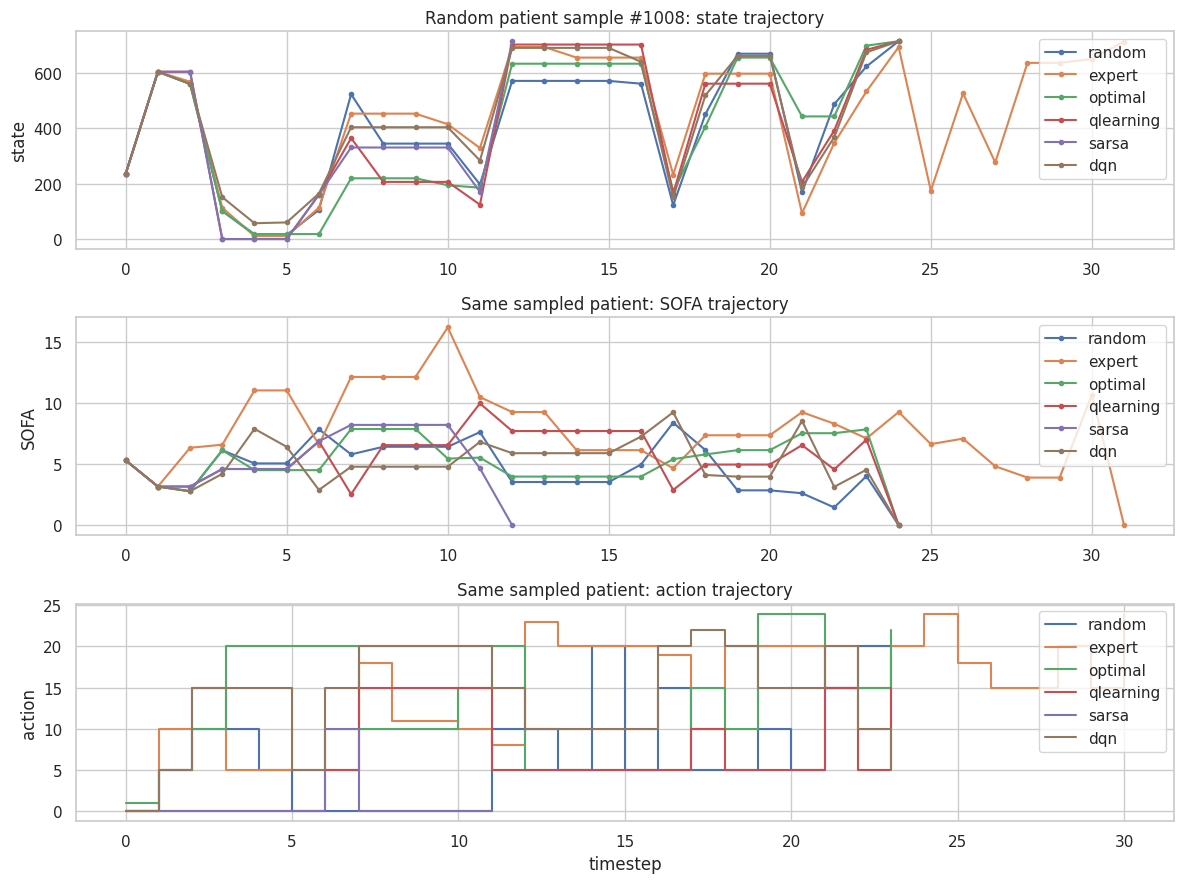

,policy,n_episodes,mean_return,std_return,stderr_return,ci95_return,mean_length,survival_rate,stderr_survival
0,optimal,2000,0.8745,0.331285,0.007408,0.014519,11.1050,0.8745,0.007408
1,ppo,2000,0.7965,0.402601,0.009002,0.017645,8.8315,0.7965,0.009002
2,dqn,2000,0.7925,0.405517,0.009068,0.017773,9.1500,0.7925,0.009068
3,qlearning,2000,0.7815,0.413228,0.009240,0.018111,7.5725,0.7815,0.009240
4,sac,2000,0.7785,0.415256,0.009285,0.018199,9.8395,0.7785,0.009285
5,expert,2000,0.7730,0.418893,0.009367,0.018359,8.8890,0.7730,0.009367
6,random,2000,0.7725,0.419218,0.009374,0.018373,9.7725,0.7725,0.009374
7,sarsa,2000,0.7690,0.421472,0.009424,0.018472,8.0230,0.7690,0.009424


In [37]:
PATIENT_SAMPLE_SEED = 25
# Pick an episode index; all policies share the same reset seeds now.
POLICIES_TO_SHOW = ["random", "expert", "optimal"] + [result["name"] for result in results[:3]]
rng = np.random.default_rng(PATIENT_SAMPLE_SEED)
selected_patient_idx = int(rng.integers(EVAL_EPISODES))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

for name in POLICIES_TO_SHOW:
    trace = traces_by_policy[name][selected_patient_idx]
    t_state = np.arange(len(trace["states"]))
    t_action = np.arange(len(trace["actions"]))
    axes[0].plot(t_state, trace["states"], marker="o", ms=3, label=name)
    axes[1].plot(t_state, trace["sofa"], marker="o", ms=3, label=name)
    axes[2].step(t_action, trace["actions"], where="post", label=name)

axes[0].set_title(f"Random patient sample #{selected_patient_idx}: state trajectory")
axes[0].set_ylabel("state")
axes[1].set_title("Same sampled patient: SOFA trajectory")
axes[1].set_ylabel("SOFA")
axes[2].set_title("Same sampled patient: action trajectory")
axes[2].set_ylabel("action")
axes[2].set_xlabel("timestep")
for ax in axes:
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

eval_df